# Project 18: Short Reads vs Long Reads (E. coli K-12 MG1655)

**Как запускать:** выполняй клетки сверху вниз (Runtime → Run all тоже можно, но лучше по одной первые 3).

1. **Клетка 1 перезапускает runtime** (так устроен condacolab). После перезапуска продолжай со **следующей** клетки, клетку 1 повторно не запускай.
2. Все тяжёлые шаги пропускаются, если результат уже есть, поэтому после сброса сессии можно просто запустить всё заново.
3. Сырые данные хранятся на Google Drive (`MyDrive/project18`), результаты сборок копируются туда же.
4. В конце (клетка 14) создаётся `results_bundle.zip`: пришли его мне (или текст, который напечатает последняя клетка).
5. Если какая-то клетка падает с ошибкой, пришли мне последние строки ошибки.

**Время:** ~1,5–3 часа в сумме на бесплатном Colab (2 ядра). Не закрывай вкладку.

## 1. Установка conda (перезапустит runtime)

In [24]:
import os, subprocess
if not os.path.exists('/usr/local/bin/conda'):
    subprocess.run(['pip', 'install', '-q', 'condacolab'], check=True)
    import condacolab
    condacolab.install()   # runtime restarts here; continue from the next cell
else:
    print('conda already installed -> go to the next cell')

conda already installed -> go to the next cell


## 2. Настройки и вспомогательные функции

In [25]:
import os, subprocess, time, json, re, glob, shutil
from pathlib import Path
from google.colab import drive
drive.mount('/content/drive')

DRIVE = Path('/content/drive/MyDrive/project18')
LOCAL = Path('/content/p18')
RAW, QCD, REFD = DRIVE/'data'/'raw', DRIVE/'data'/'qc', DRIVE/'data'/'ref'
for p in [RAW, QCD, REFD, DRIVE/'p18_out', LOCAL/'sub', LOCAL/'asm', LOCAL/'logs',
          LOCAL/'results'/'qc', LOCAL/'results'/'figures']:
    p.mkdir(parents=True, exist_ok=True)
os.chdir(LOCAL)
os.environ['PATH'] = '/usr/local/envs/p18/bin:' + os.environ['PATH']

# ---------------- configuration ----------------
SHORT_ACC = 'SRR1030394'      # Illumina MiSeq 2x251, MG1655
LONG_ACC  = 'ERR14686234'     # Nanopore MinION, MG1655 (~36x)
REF_ACC   = 'GCF_000005845.2'
REF_URL   = 'https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/GCF_000005845.2_ASM584v2/GCF_000005845.2_ASM584v2_genomic.fna.gz'
GS        = 4641652           # reference genome length, bp
COVS      = [10, 20, 30]      # coverage levels for short-only and long-only assemblies
HYBRID    = [(30, 20)]        # (short coverage, long coverage) pairs for hybrid assemblies
SEED      = 42
T         = 2                 # threads (free Colab has 2 cores)
FLYE_MODE = '--nano-raw'      # use --nano-hq if the reads are Guppy5+/R10
REF       = str(REFD/'ref.fasta')
# -----------------------------------------------

RT = LOCAL/'results'/'runtime.csv'
if not RT.exists():
    RT.write_text('step,seconds,exit_code\n')

def sh(cmd, label='cmd', check=True, show=False):
    # run a bash command, log full output to logs/<label>.log, print only the tail
    t0 = time.time()
    log = LOCAL/'logs'/f'{label}.log'
    print(f'[{label}] started...', flush=True)
    with open(log, 'w') as f:
        p = subprocess.run(['bash', '-o', 'pipefail', '-c', cmd], stdout=f, stderr=subprocess.STDOUT)
    dt = time.time() - t0
    with open(RT, 'a') as f:
        f.write(f'{label},{dt:.1f},{p.returncode}\n')
    lines = open(log).read().strip().split('\n')
    print('\n'.join(lines if show else lines[-6:]))
    print(f'[{label}] exit={p.returncode} time={dt:.0f}s', flush=True)
    if p.returncode != 0 and check:
        raise RuntimeError(f'{label} failed, see {log}')
    return p.returncode

FILTER = ['--exclude=sub/', '--exclude=tmp/', '--exclude=corrected/', '--include=*/',
          '--include=*.fasta', '--include=*.gfa', '--include=*.log', '--include=*.tsv', '--include=*.csv',
          '--include=*.txt', '--include=*.json', '--include=*.html', '--include=*.png', '--include=*.yml',
          '--include=*.vcf', '--exclude=*']

def persist():
    # copy small results to Drive so they survive a runtime reset
    subprocess.run(['rsync', '-a'] + FILTER + [f'{LOCAL}/', f'{DRIVE}/p18_out/'])

def restore():
    if (DRIVE/'p18_out').exists():
        subprocess.run(['rsync', '-a', f'{DRIVE}/p18_out/', f'{LOCAL}/'])

restore()
print('ready')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ready


## 3. Окружение (SPAdes, Flye, Unicycler, QUAST, minimap2, fastp, NanoPlot, rasusa)

In [26]:
if not Path('/usr/local/envs/p18/bin/spades.py').exists():
    sh('conda create -y -q -n p18 -c conda-forge -c bioconda python=3.11 spades flye unicycler quast '
       'minimap2 samtools bcftools fastp nanoplot rasusa seqkit pandas matplotlib', 'conda_create')
sh('conda env export -n p18 > results/environment.lock.yml; '
   'spades.py --version; flye --version; unicycler --version; quast.py --version | head -1; '
   'fastp --version; rasusa --version; minimap2 --version', 'versions', show=True)

[versions] started...
SPAdes genome assembler v4.3.0
2.9.6-b1802
Unicycler v0.5.1
QUAST v5.3.0
fastp 1.4.0
rasusa 5.1.0
2.31-r1302
[versions] exit=0 time=8s


0

## 4. Метаданные из ENA и проверка покрытия

In [27]:
import pandas as pd

def ena_meta(acc):
    f = ('run_accession,scientific_name,sample_title,instrument_model,library_strategy,library_layout,'
         'read_count,base_count,fastq_ftp,fastq_md5')
    url = f'https://www.ebi.ac.uk/ena/portal/api/filereport?accession={acc}&result=read_run&fields={f}&format=tsv'
    out = subprocess.run(['curl', '-s', url], capture_output=True, text=True).stdout.strip().split('\n')
    return dict(zip(out[0].split('\t'), out[1].split('\t')))

META = {'short': ena_meta(SHORT_ACC), 'long': ena_meta(LONG_ACC)}
for k, m in META.items():
    m['coverage_x'] = round(int(m['base_count']) / GS, 1)
    m['mean_read_len'] = round(int(m['base_count']) / int(m['read_count']))
    if 'MG1655' not in m['scientific_name']:
        print('WARNING: not MG1655 ->', k)
df = pd.DataFrame(META).T.drop(columns=['fastq_ftp', 'fastq_md5'])
df.to_csv('results/metadata.tsv', sep='\t')
print(df.T.to_string())

                                                                                 short                                       long
run_accession                                                               SRR1030394                                ERR14686234
scientific_name                              Escherichia coli str. K-12 substr. MG1655  Escherichia coli str. K-12 substr. MG1655
sample_title      MIGS Cultured Bacterial/Archaeal sample from Escherichia coli MG1655         Ciprofloxacin resistant mutant C57
instrument_model                                                        Illumina MiSeq                                     MinION
library_strategy                                                                   WGS                                        WGS
library_layout                                                                  PAIRED                                     SINGLE
read_count                                                                     2720956    

## 5. Скачивание данных (на Google Drive, с проверкой md5)

In [28]:
SR1, SR2 = RAW/f'{SHORT_ACC}_1.fastq.gz', RAW/f'{SHORT_ACC}_2.fastq.gz'
LR = RAW/f'{LONG_ACC}.fastq.gz'
prov = []

def md5(p):
    return subprocess.run(['md5sum', str(p)], capture_output=True, text=True).stdout.split()[0]

def fetch(meta):
    for u, m in zip(meta['fastq_ftp'].split(';'), meta['fastq_md5'].split(';')):
        dest = RAW/os.path.basename(u)
        if not (dest.exists() and md5(dest) == m):
            sh(f'wget -c -q -P {RAW} https://{u}', f'download_{dest.name}')
        assert md5(dest) == m, f'md5 mismatch: {dest}'
        prov.append(f'{meta["run_accession"]}\t{dest.name}\t{u}\t{m}\t{time.strftime("%Y-%m-%d")}')

fetch(META['short'])
fetch(META['long'])

if not Path(REF).exists():
    sh(f'wget -q -O {REFD}/ref.fna.gz {REF_URL} && gunzip -c {REFD}/ref.fna.gz > {REF}', 'download_ref')
prov.append(f'{REF_ACC}\tref.fasta\t{REF_URL}\t-\t{time.strftime("%Y-%m-%d")}')
Path('results/PROVENANCE.tsv').write_text('accession\tfile\tsource\tmd5\tretrieved\n' + '\n'.join(prov) + '\n')
sh(f'grep ">" {REF}; samtools faidx {REF}; cut -f1,2 {REF}.fai', 'ref_check', show=True)

[ref_check] started...
>NC_000913.3 Escherichia coli str. K-12 substr. MG1655, complete genome
NC_000913.3	4641652
[ref_check] exit=0 time=0s


0

## 6. Проверка штамма (задание 2 хэндбука)
Short reads → референс: доля выровненных ридов и число SNP/indel. Для того же штамма их должно быть очень мало.

In [29]:
v1, v2 = 'sub/verify_R1.fq.gz', 'sub/verify_R2.fq.gz'
if not Path(v1).exists():
    sh(f'rasusa reads -c 30 -g {GS} -s {SEED} -o {v1} -o {v2} {SR1} {SR2}', 'verify_subsample_short')
sh(f'minimap2 -t {T} -ax sr {REF} {v1} {v2} | samtools sort -@ {T} -o results/verify_short.bam - '
   f'&& samtools index results/verify_short.bam && samtools flagstat results/verify_short.bam > results/verify_short.flagstat.txt',
   'verify_map_short')
sh(f'bcftools mpileup -f {REF} -Ou results/verify_short.bam | bcftools call -mv --ploidy 1 -Ov -o results/verify_short.vcf',
   'verify_call_short')
sh(f'minimap2 -t {T} -ax map-ont {REF} {LR} | samtools sort -@ {T} -o results/verify_long.bam - '
   f'&& samtools index results/verify_long.bam && samtools flagstat results/verify_long.bam > results/verify_long.flagstat.txt',
   'verify_map_long')

snps = indels = 0
for line in open('results/verify_short.vcf'):
    if line.startswith('#'):
        continue
    c = line.rstrip().split('\t')
    qual = float(c[5]) if c[5] != '.' else 0
    dp = re.search(r'DP=(\d+)', c[7])
    dp = int(dp.group(1)) if dp else 0
    if qual < 30 or dp < 10:
        continue
    if 'INDEL' in c[7]:
        indels += 1
    else:
        snps += 1

txt = ('STRAIN CHECK\n'
       f'short reads (30x subsample) vs reference: SNPs={snps}, indels={indels} (QUAL>=30, DP>=10)\n'
       '--- flagstat short ---\n' + open('results/verify_short.flagstat.txt').read() +
       '--- flagstat long ---\n' + open('results/verify_long.flagstat.txt').read())
Path('results/strain_check.txt').write_text(txt)
print(txt)
persist()

[verify_map_short] started...
[M::worker_pipeline::41.447*1.37] mapped 206172 sequences
[M::worker_pipeline::50.558*1.42] mapped 161452 sequences
[M::main] Version: 2.31-r1302
[M::main] CMD: minimap2 -t 2 -ax sr /content/drive/MyDrive/project18/data/ref/ref.fasta sub/verify_R1.fq.gz sub/verify_R2.fq.gz
[M::main] Real time: 50.589 sec; CPU: 71.983 sec; Peak RSS: 0.405 GB
[bam_sort_core] merging from 0 files and 2 in-memory blocks...
[verify_map_short] exit=0 time=60s
[verify_call_short] started...
[mpileup] 1 samples in 1 input files
[mpileup] maximum number of reads per input file set to -d 250
[verify_call_short] exit=0 time=46s
[verify_map_long] started...
[M::mm_idx_stat::0.328*1.12] distinct minimizers: 838542 (98.18% are singletons); average occurrences: 1.034; average spacing: 5.352; total length: 4641652
[M::worker_pipeline::76.123*1.59] mapped 74354 sequences
[M::main] Version: 2.31-r1302
[M::main] CMD: minimap2 -t 2 -ax map-ont /content/drive/MyDrive/project18/data/ref/ref.fas

## 7. QC: короткие риды (fastp) и длинные риды (NanoPlot)
Порогов не меняй вслепую: в отчёте нужно **обосновать** каждый порог по графикам из `results/qc/`.

In [30]:
T1, T2 = QCD/'short_R1.trim.fq.gz', QCD/'short_R2.trim.fq.gz'
if not T1.exists():
    sh(f'fastp -i {SR1} -I {SR2} -o {T1} -O {T2} --detect_adapter_for_pe -q 20 -l 100 '
       f'--cut_tail --cut_tail_mean_quality 20 -w {T} -j results/qc/fastp.json -h results/qc/fastp.html', 'qc_fastp')
j = json.load(open('results/qc/fastp.json'))
b, a = j['summary']['before_filtering'], j['summary']['after_filtering']
qc_txt = ('FASTP (short reads)\n'
          f"reads before/after: {b['total_reads']} / {a['total_reads']}\n"
          f"bases before/after: {b['total_bases']} / {a['total_bases']}\n"
          f"Q30 rate before/after: {b['q30_rate']:.3f} / {a['q30_rate']:.3f}\n"
          f"mean len R1/R2 before: {b['read1_mean_length']} / {b['read2_mean_length']}; after: {a['read1_mean_length']} / {a['read2_mean_length']}\n"
          f"duplication rate: {j['duplication']['rate']:.4f}\n"
          f"adapter-trimmed reads: {j.get('adapter_cutting', {}).get('adapter_trimmed_reads')}\n"
          f"filtering result: {j['filtering_result']}\n")
Path('results/qc/qc_summary.txt').write_text(qc_txt)
print(qc_txt)

if not Path('results/qc/nanoplot/NanoStats.txt').exists():
    sh(f'NanoPlot --fastq {LR} -t {T} -o results/qc/nanoplot --loglength', 'qc_nanoplot')
print(open('results/qc/nanoplot/NanoStats.txt').read())
persist()

FASTP (short reads)
reads before/after: 5441912 / 4433204
bases before/after: 1322136908 / 1062735631
Q30 rate before/after: 0.779 / 0.852
mean len R1/R2 before: 242 / 243; after: 242 / 236
duplication rate: 0.0012
adapter-trimmed reads: 60204
filtering result: {'passed_filter_reads': 4433204, 'low_quality_reads': 934334, 'too_many_N_reads': 0, 'adapter_dimer_reads': 0, 'too_short_reads': 74374, 'too_long_reads': 0}

General summary:         
Mean read length:                2,247.4
Mean read quality:                  12.9
Median read length:              1,037.0
Median read quality:                13.3
Number of reads:                74,354.0
Read length N50:                 4,982.0
STDEV read length:               3,530.4
Total bases:               167,106,193.0
Number, percentage and megabases of reads above quality cutoffs
>Q10:	71302 (95.9%) 160.8Mb
>Q15:	13344 (17.9%) 25.9Mb
>Q20:	74 (0.1%) 0.0Mb
>Q25:	0 (0.0%) 0.0Mb
>Q30:	0 (0.0%) 0.0Mb
Top 5 highest mean basecall quality scores

## 8. Сабсэмплинг по покрытию (rasusa, seed=42)

In [31]:
short_avail = a['total_bases'] / GS
long_avail = int(META['long']['base_count']) / GS
need_s = [c for c in sorted(set(COVS) | {h[0] for h in HYBRID}) if c <= short_avail]
need_l = [c for c in sorted(set(COVS) | {h[1] for h in HYBRID}) if c <= long_avail * 0.98]
print(f'available coverage: short {short_avail:.0f}x, long {long_avail:.1f}x')
print('short levels:', need_s, '| long levels:', need_l)

for c in need_s:
    o1, o2 = f'sub/short_{c}x_R1.fq.gz', f'sub/short_{c}x_R2.fq.gz'
    if not Path(o1).exists():
        sh(f'rasusa reads -c {c} -g {GS} -s {SEED} -o {o1} -o {o2} {T1} {T2}', f'sub_short_{c}x')
for c in need_l:
    o = f'sub/long_{c}x.fq.gz'
    if not Path(o).exists():
        sh(f'rasusa reads -c {c} -g {GS} -s {SEED} -o {o} {LR}', f'sub_long_{c}x')

available coverage: short 229x, long 36.0x
short levels: [10, 20, 30] | long levels: [10, 20, 30]


## 9. Сборка short-only (SPAdes), ~10–15 мин на уровень

In [32]:
for c in [c for c in COVS if c in need_s]:
    out = f'asm/short_{c}x'
    if Path(out, 'contigs.fasta').exists():
        continue
    sh(f'spades.py --isolate -1 sub/short_{c}x_R1.fq.gz -2 sub/short_{c}x_R2.fq.gz -t {T} -m 10 -o {out}',
       f'spades_{c}x', check=False)
    persist()

## 10. Сборка long-only (Flye), ~15–30 мин на уровень

In [33]:
for c in [c for c in COVS if c in need_l]:
    out = f'asm/long_{c}x'
    if Path(out, 'assembly.fasta').exists():
        continue
    sh(f'flye {FLYE_MODE} sub/long_{c}x.fq.gz --out-dir {out} --threads {T}', f'flye_{c}x', check=False)
    persist()

## 11. Hybrid-сборка (Unicycler), может занять 30–60 мин

In [34]:
for s, l in HYBRID:
    out = f'asm/hybrid_s{s}_l{l}'
    if Path(out, 'assembly.fasta').exists() or s not in need_s or l not in need_l:
        continue
    sh(f'unicycler -1 sub/short_{s}x_R1.fq.gz -2 sub/short_{s}x_R2.fq.gz -l sub/long_{l}x.fq.gz -o {out} -t {T}',
       f'unicycler_s{s}_l{l}', check=False)
    persist()

[unicycler_s30_l20] started...
where c is the contig count and d is the dead end count.

spades.py -o /content/p18/asm/hybrid_s30_l20/spades_assembly -k 27 --threads 2 --gfa11 --isolate -1 /content/p18/sub/short_30x_R1.fq.gz -2 /content/p18/sub/short_30x_R2.fq.gz -m 1024

spades.py -o /content/p18/asm/hybrid_s30_l20/spades_assembly -k 27,53 --threads 2 --gfa11 --restart-from k27 -m 1024
Error: SPAdes failed to produce an assembly graph: /content/p18/asm/hybrid_s30_l20/spades_assembly/K53/assembly_graph_with_scaffolds.gfa
[unicycler_s30_l20] exit=1 time=590s


## 12. Оценка сборок против референса (QUAST)

In [35]:
cands = []
for p in sorted(glob.glob('asm/short_*x/contigs.fasta')):
    cands.append((Path(p).parent.name, p))
for p in sorted(glob.glob('asm/long_*x/assembly.fasta')):
    cands.append((Path(p).parent.name, p))
for p in sorted(glob.glob('asm/hybrid_*/assembly.fasta')):
    cands.append((Path(p).parent.name, p))
cands = [(l, p) for l, p in cands if os.path.getsize(p) > 0]
print('assemblies found:', [l for l, _ in cands])

sh('rm -rf results/quast')
sh(f'quast.py -r {REF} -t {T} --min-contig 500 --no-icarus -o results/quast '
   + ' '.join(p for _, p in cands) + ' --labels ' + ','.join(l for l, _ in cands), 'quast', show=True)
persist()

assemblies found: ['short_10x', 'short_20x', 'short_30x', 'long_10x', 'long_20x', 'long_30x']
[cmd] started...

[cmd] exit=0 time=0s
[quast] started...
/usr/local/envs/p18/bin/quast.py -r /content/drive/MyDrive/project18/data/ref/ref.fasta -t 2 --min-contig 500 --no-icarus -o results/quast asm/short_10x/contigs.fasta asm/short_20x/contigs.fasta asm/short_30x/contigs.fasta asm/long_10x/assembly.fasta asm/long_20x/assembly.fasta asm/long_30x/assembly.fasta --labels short_10x,short_20x,short_30x,long_10x,long_20x,long_30x

Version: 5.3.0

System information:
  OS: Linux-6.6.122+-x86_64-with-glibc2.39 (linux_64)
  Python version: 3.11.17
  CPUs number: 2

Started: 2026-10-08 11:37:31

Logging to /content/p18/results/quast/quast.log

CWD: /content/p18
Main parameters: 
  MODE: default, threads: 2, min contig length: 500, min alignment length: 65, min alignment IDY: 95.0, \
  ambiguity: one, min local misassembly length: 200, min extensive misassembly length: 1000


Reference:
  /content/dri

## 13. Сводная таблица и графики

    label  # contigs  Total length  Largest contig     N50  NGA50  # misassemblies  Genome fraction (%)  # mismatches per 100 kbp  # indels per 100 kbp
short_10x        269       4554652          181763   37753  35106               10               97.889                     22.21                  0.97
short_20x         87       4558219          414105  132704 112487                5               98.100                      3.82                  0.44
short_30x         76       4558864          414105  139821 132704                5               98.130                      1.49                  0.24
 long_10x         64       4651795          364004  184555 172313                9               97.904                     49.44                120.04
 long_20x          6       4726948         2058693 1535391 941673                9               99.794                      6.02                 36.62
 long_30x          6       9462452         3274133 3274130      -                0      

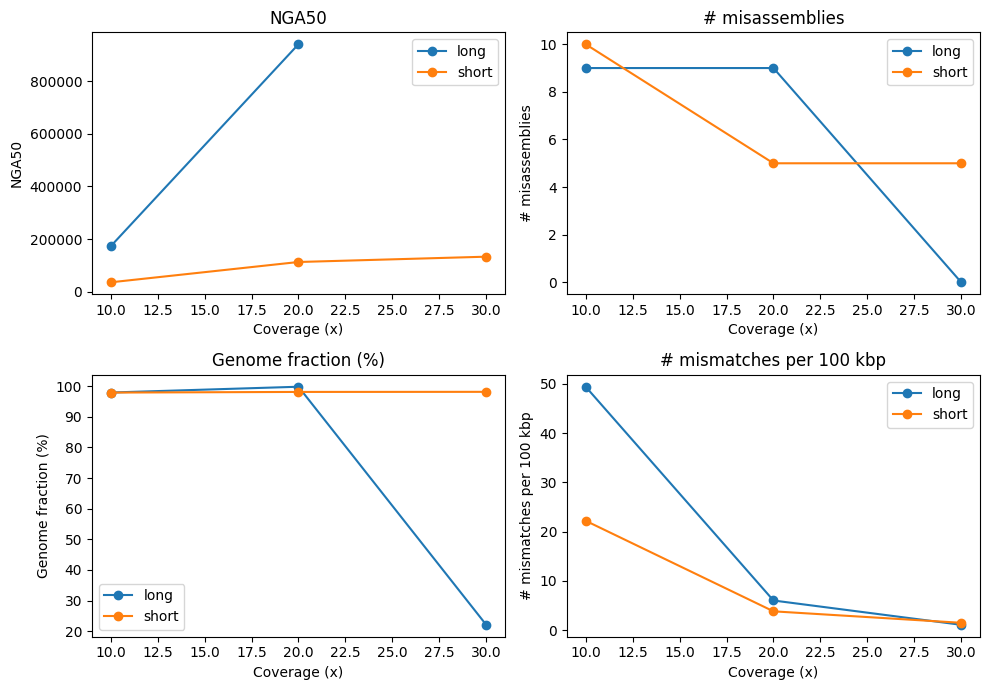

In [36]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

q = pd.read_csv('results/quast/transposed_report.tsv', sep='\t').rename(columns={'Assembly': 'label'})
q['strategy'] = q['label'].str.split('_').str[0]
q['cov'] = q['label'].apply(lambda s: int(re.findall(r'(\d+)', s)[-1]))   # hybrid -> long coverage

cols = ['label', '# contigs', 'Total length', 'Largest contig', 'N50', 'NGA50', '# misassemblies',
        'Genome fraction (%)', '# mismatches per 100 kbp', '# indels per 100 kbp']
cols = [c for c in cols if c in q.columns]
tab = q[cols]
tab.to_csv('results/assembly_summary.csv', index=False)
print(tab.to_string(index=False))

metrics = [m for m in ['NGA50', '# misassemblies', 'Genome fraction (%)', '# mismatches per 100 kbp'] if m in q.columns]
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, m in zip(axes.ravel(), metrics):
    for s, g in q.groupby('strategy'):
        g = g.sort_values('cov')
        ax.plot(g['cov'], pd.to_numeric(g[m], errors='coerce'), 'o-', label=s)
    ax.set_xlabel('Coverage (x)'); ax.set_ylabel(m); ax.set_title(m); ax.legend()
fig.tight_layout()
fig.savefig('results/figures/assembly_metrics_vs_coverage.png', dpi=200)
plt.show()
persist()

## 14. Итог: напечатать сводку и собрать архив для отправки

In [37]:
persist()
parts = []
for f in ['results/metadata.tsv', 'results/strain_check.txt', 'results/qc/qc_summary.txt',
          'results/qc/nanoplot/NanoStats.txt', 'results/assembly_summary.csv', 'results/runtime.csv']:
    if Path(f).exists():
        parts.append(f'===== {f} =====\n' + Path(f).read_text())
summary = '\n'.join(parts)
Path('RESULTS_SUMMARY.txt').write_text(summary)
print(summary)

import zipfile
with zipfile.ZipFile('results_bundle.zip', 'w', zipfile.ZIP_DEFLATED) as z:
    for root in ['results', 'logs']:
        for p in Path(root).rglob('*'):
            if p.is_file() and p.suffix not in ('.bam', '.bai') and p.stat().st_size < 20_000_000:
                z.write(p)
    z.write('RESULTS_SUMMARY.txt')
shutil.copy('results_bundle.zip', DRIVE/'results_bundle.zip')
from google.colab import files
files.download('results_bundle.zip')

===== results/metadata.tsv =====
	run_accession	scientific_name	sample_title	instrument_model	library_strategy	library_layout	read_count	base_count	coverage_x	mean_read_len
short	SRR1030394	Escherichia coli str. K-12 substr. MG1655	MIGS Cultured Bacterial/Archaeal sample from Escherichia coli MG1655	Illumina MiSeq	WGS	PAIRED	2720956	1322136908	284.8	486
long	ERR14686234	Escherichia coli str. K-12 substr. MG1655	Ciprofloxacin resistant mutant C57	MinION	WGS	SINGLE	74354	167106193	36.0	2247

===== results/strain_check.txt =====
STRAIN CHECK
short reads (30x subsample) vs reference: SNPs=2, indels=3 (QUAL>=30, DP>=10)
--- flagstat short ---
574396 + 0 in total (QC-passed reads + QC-failed reads)
573348 + 0 primary
0 + 0 secondary
1048 + 0 supplementary
0 + 0 duplicates
0 + 0 primary duplicates
565648 + 0 mapped (98.48% : N/A)
564600 + 0 primary mapped (98.47% : N/A)
573348 + 0 paired in sequencing
286674 + 0 read1
286674 + 0 read2
531146 + 0 properly paired (92.64% : N/A)
556526 + 0 with 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>